<a href="https://colab.research.google.com/github/Vladislav-spect/DeepLearningSchool/blob/main/Project/3_Pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Задание 3. Полный пайплайн распознавания лиц

Собираю три части вместе: детекция → выравнивание (Hourglass из Задания 1) → распознавание
(сеть из Задания 2). На вход — обычное фото, на выходе — эмбеддинг для каждого найденного лица.
В конце проверяю на паре фото одного человека и разных людей.

По правилам детектор можно брать готовый. Я беру встроенный в OpenCV детектор лиц (Haar cascade) —
он не требует никаких установок и сразу работает. Если хочется точнее, его легко заменить на
MTCNN или RetinaFace. А вот точки и эмбеддинг — это уже мои модели из Заданий 1 и 2.

## 0. Настройки и веса

In [3]:
import os, math, glob
import numpy as np, cv2
import matplotlib.pyplot as plt
import torch, torch.nn as nn, torch.nn.functional as F
import torchvision

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
WORK_DIR = "/content/drive/MyDrive/face_project"
INPUT_SIZE, HEATMAP_SIZE, ALIGNED_SIZE, EMB_DIM = 256, 64, 112, 512
MEAN = torch.tensor([0.485,0.456,0.406]).view(3,1,1)
STD  = torch.tensor([0.229,0.224,0.225]).view(3,1,1)
print("device:", DEVICE)

# --- Монтирование Google Drive (безопасно к повторному запуску) ---
import shutil
try:
    from google.colab import drive
    if os.path.ismount('/content/drive'):
        print('Google Drive уже смонтирован.')
    else:
        if os.path.isdir('/content/drive') and os.listdir('/content/drive'):
            shutil.rmtree('/content/drive', ignore_errors=True)
        drive.mount('/content/drive')
except ModuleNotFoundError:
    print('Не Colab-окружение — монтирование Drive пропущено.')

device: cuda
Google Drive уже смонтирован.


## 1. Модели из Заданий 1 и 2

Ноутбук самодостаточный, поэтому коротко повторяю определения сетей и функций (точки, выравнивание)
и загружаю сохранённые веса.

In [4]:
class ResidualBlock(nn.Module):
    def __init__(self, ci, co):
        super().__init__()
        self.skip = nn.Identity() if ci==co else nn.Conv2d(ci, co, 1)
        self.conv1, self.bn1 = nn.Conv2d(ci, co//2, 1), nn.BatchNorm2d(co//2)
        self.conv2, self.bn2 = nn.Conv2d(co//2, co//2, 3, padding=1), nn.BatchNorm2d(co//2)
        self.conv3, self.bn3 = nn.Conv2d(co//2, co, 1), nn.BatchNorm2d(co)
        self.relu = nn.ReLU(inplace=True)
    def forward(self, x):
        r = self.skip(x)
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.relu(self.bn2(self.conv2(x)))
        return self.relu(self.bn3(self.conv3(x)) + r)

class Hourglass(nn.Module):
    def __init__(self, depth, ch):
        super().__init__()
        self.skip, self.pool = ResidualBlock(ch,ch), nn.MaxPool2d(2,2)
        self.before = ResidualBlock(ch,ch)
        self.inner  = Hourglass(depth-1, ch) if depth>1 else ResidualBlock(ch,ch)
        self.after  = ResidualBlock(ch,ch); self.up = nn.Upsample(scale_factor=2, mode="nearest")
    def forward(self, x):
        s = self.skip(x)
        return s + self.up(self.after(self.inner(self.before(self.pool(x)))))

class StackedHourglass(nn.Module):
    def __init__(self, num_stacks=2, num_landmarks=5, ch=256, depth=4):
        super().__init__()
        self.stem = nn.Sequential(nn.Conv2d(3,64,7,2,3), nn.BatchNorm2d(64), nn.ReLU(True),
            ResidualBlock(64,128), nn.MaxPool2d(2,2), ResidualBlock(128,128), ResidualBlock(128,ch))
        self.hgs   = nn.ModuleList([Hourglass(depth,ch) for _ in range(num_stacks)])
        self.feats = nn.ModuleList([nn.Sequential(ResidualBlock(ch,ch), nn.Conv2d(ch,ch,1),
                        nn.BatchNorm2d(ch), nn.ReLU(True)) for _ in range(num_stacks)])
        self.heads = nn.ModuleList([nn.Conv2d(ch, num_landmarks, 1) for _ in range(num_stacks)])
        self.merge_feat = nn.ModuleList([nn.Conv2d(ch,ch,1) for _ in range(num_stacks-1)])
        self.merge_pred = nn.ModuleList([nn.Conv2d(num_landmarks,ch,1) for _ in range(num_stacks-1)])
    def forward(self, x):
        x = self.stem(x); outs = []
        for i in range(len(self.hgs)):
            feat = self.feats[i](self.hgs[i](x)); pred = self.heads[i](feat); outs.append(pred)
            if i < len(self.hgs)-1:
                x = x + self.merge_feat[i](feat) + self.merge_pred[i](pred)
        return outs

class FaceEmbeddingNet(nn.Module):
    def __init__(self, emb_dim=EMB_DIM, backbone="resnet50"):
        super().__init__()
        net = getattr(torchvision.models, backbone)(weights=None)
        in_feats = net.fc.in_features; net.fc = nn.Identity(); self.backbone = net
        self.embedding = nn.Sequential(nn.Linear(in_feats, emb_dim), nn.BatchNorm1d(emb_dim))
    def forward(self, x, normalize=False):
        emb = self.embedding(self.backbone(x))
        return F.normalize(emb) if normalize else emb

In [5]:
REFERENCE_5PTS = np.array([[38.2946,51.6963],[73.5318,51.5014],[56.0252,71.7366],
                           [41.5493,92.3655],[70.7299,92.2041]], dtype=np.float32)

def decode_heatmaps(hm, input_size=INPUT_SIZE, heatmap_size=HEATMAP_SIZE):
    if torch.is_tensor(hm): hm = hm.detach().cpu().numpy()
    K, H, W = hm.shape; pts = np.zeros((K,2), np.float32)
    for k in range(K):
        y, x = np.unravel_index(hm[k].argmax(), (H, W)); pts[k] = [x, y]
    return pts * (input_size / heatmap_size)

def align_face(img, landmarks, out_size=ALIGNED_SIZE, ref=REFERENCE_5PTS):
    M, _ = cv2.estimateAffinePartial2D(np.asarray(landmarks, np.float32),
                                       ref * (out_size/112.0), method=cv2.LMEDS)
    if M is None:
        return cv2.resize(img, (out_size, out_size))
    return cv2.warpAffine(img, M, (out_size, out_size), borderValue=0)

# загружаем веса из Заданий 1 и 2
hourglass = StackedHourglass().to(DEVICE).eval()
hourglass.load_state_dict(torch.load(os.path.join(WORK_DIR, "hourglass_best.pt"), map_location=DEVICE))

embnet = FaceEmbeddingNet().to(DEVICE).eval()
embnet.load_state_dict(torch.load(os.path.join(WORK_DIR, "embnet_arcface.pt"), map_location=DEVICE))

# детектор лиц (встроенный в OpenCV, без установок)
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_default.xml")
print("Модели и детектор загружены.")

Модели и детектор загружены.


## 2. Пайплайн

Логика на одно лицо: детектор находит рамку → расширяю и обрезаю → Hourglass находит 5 точек →
выравниваю → сеть-распознаватель выдаёт нормированный эмбеддинг.

In [6]:
class FacePipeline:
    def __init__(self, cascade, hourglass, embnet, margin=0.35):
        self.cascade, self.hg, self.emb, self.margin = cascade, hourglass, embnet, margin

    def detect(self, image_bgr):
        gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)
        boxes = self.cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(40,40))
        return [(x, y, x+w, y+h) for (x, y, w, h) in boxes]   # -> (x1,y1,x2,y2)

    def _landmarks(self, face_bgr):
        face = cv2.cvtColor(cv2.resize(face_bgr, (INPUT_SIZE, INPUT_SIZE)), cv2.COLOR_BGR2RGB)
        x = (torch.from_numpy(face).permute(2,0,1).float()/255.0 - MEAN)/STD
        with torch.no_grad():
            hm = self.hg(x.unsqueeze(0).to(DEVICE))[-1][0]
        return decode_heatmaps(hm), face

    def _embed(self, aligned_rgb):
        x = (torch.from_numpy(aligned_rgb).permute(2,0,1).float()/255.0 - MEAN)/STD
        with torch.no_grad():
            return self.emb(x.unsqueeze(0).to(DEVICE), normalize=True)[0].cpu().numpy()

    def __call__(self, image_bgr):
        H, W = image_bgr.shape[:2]
        results = []
        for (x1, y1, x2, y2) in self.detect(image_bgr):
            bw, bh = x2-x1, y2-y1
            dx, dy = int(bw*self.margin), int(bh*self.margin)
            xa, ya, xb, yb = max(0,x1-dx), max(0,y1-dy), min(W,x2+dx), min(H,y2+dy)
            crop = image_bgr[ya:yb, xa:xb]
            if crop.size == 0: continue
            pts, face_rgb = self._landmarks(crop)
            aligned = align_face(face_rgb, pts)
            results.append({"bbox": (x1,y1,x2,y2), "aligned": aligned, "embedding": self._embed(aligned)})
        return results

pipe = FacePipeline(face_cascade, hourglass, embnet)
print("Пайплайн готов: pipe(image_bgr) -> [{bbox, aligned, embedding}, ...]")

Пайплайн готов: pipe(image_bgr) -> [{bbox, aligned, embedding}, ...]


## 3. Проверка на фото

Положите 2–3 фотографии в папку `face_project/demo/` (два разных фото одного человека и одно фото
другого). Ожидаем: у одного человека косинусное сходство высокое, у разных — низкое.

In [11]:
import os, glob, shutil
WORK = "/content/drive/MyDrive/face_project"
demo = os.path.join(WORK, "demo"); os.makedirs(demo, exist_ok=True)
root = "/content/aligned" if os.path.isdir("/content/aligned") else os.path.join(WORK, "aligned")
ids = sorted(glob.glob(os.path.join(root, "train", "*")))
a = sorted(glob.glob(os.path.join(ids[0], "*")))[:2]    # 2 фото одного человека
b = sorted(glob.glob(os.path.join(ids[1], "*")))[:1]    # 1 фото другого
shutil.copy(a[0], os.path.join(demo, "personA_1.jpg"))
shutil.copy(a[1], os.path.join(demo, "personA_2.jpg"))
shutil.copy(b[0], os.path.join(demo, "personB_1.jpg"))
print("в demo:", os.listdir(demo))

в demo: ['personA_1.jpg', 'personA_2.jpg', 'personB_1.jpg']


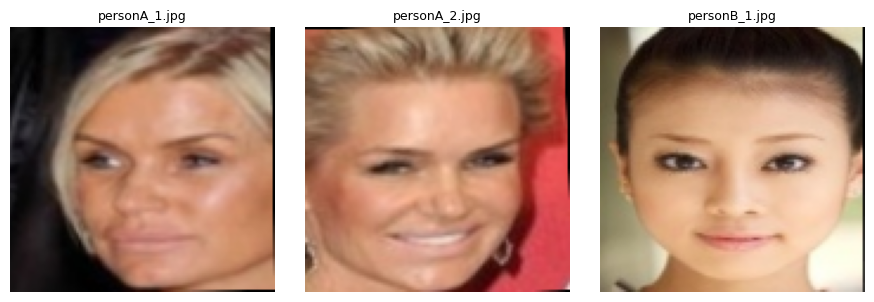

Косинусное сходство по парам:
       personA_1.jpg  <->  personA_2.jpg       cos = 0.875
       personA_1.jpg  <->  personB_1.jpg       cos = 0.064
       personA_2.jpg  <->  personB_1.jpg       cos = 0.052


In [12]:
def cosine(a, b):
    return float(np.dot(a, b))      # эмбеддинги уже нормированы

demo_dir = os.path.join(WORK_DIR, "demo")
os.makedirs(demo_dir, exist_ok=True)
paths = sorted(glob.glob(os.path.join(demo_dir, "*.jpg")) + glob.glob(os.path.join(demo_dir, "*.png")))

faces, embs = [], []
if len(paths) < 2:
    print("Надо положить 2-3 фото (jpg/png) в", demo_dir, "и перезапустить ячейку.")
else:
    for p in paths:
        res = pipe(cv2.imread(p))
        if not res:
            print("Лицо не найдено:", os.path.basename(p)); continue
        faces.append((os.path.basename(p), res[0]["aligned"])); embs.append(res[0]["embedding"])

    # показываем найденные лица
    plt.figure(figsize=(3*len(faces), 3))
    for i, (name, f) in enumerate(faces):
        plt.subplot(1, len(faces), i+1); plt.imshow(f); plt.axis("off"); plt.title(name, fontsize=9)
    plt.tight_layout(); plt.show()

    # попарные сходства
    print("Косинусное сходство по парам:")
    for i in range(len(embs)):
        for j in range(i+1, len(embs)):
            print(f"  {faces[i][0]:>18}  <->  {faces[j][0]:<18}  cos = {cosine(embs[i], embs[j]):.3f}")

In [13]:
# Порог «тот же человек / разные» удобно выбирать по метрике ID-Rate (доп. задание 1).
THRESHOLD = 0.4
if len(paths) >= 2 and len(embs) >= 2:
    for i in range(len(embs)):
        for j in range(i+1, len(embs)):
            s = cosine(embs[i], embs[j])
            verdict = "один человек" if s > THRESHOLD else "разные люди"
            print(f"{faces[i][0]} <-> {faces[j][0]}: cos={s:.3f} -> {verdict}")

personA_1.jpg <-> personA_2.jpg: cos=0.875 -> один человек
personA_1.jpg <-> personB_1.jpg: cos=0.064 -> разные люди
personA_2.jpg <-> personB_1.jpg: cos=0.052 -> разные люди


## Итого

Собрал сквозной пайплайн: детектор (OpenCV) → мой Hourglass (точки + выравнивание) → мой
распознаватель (эмбеддинг). На вход любое фото, на выходе эмбеддинг каждого лица. По косинусному
сходству видно, один человек на фото или разные.

Порог лучше выбирать не на глаз, а по метрике ID-Rate из доп. задания 1.